In [1]:
# =====================================================
# Deep Learning & Transformers
# Name: Abdulaziz Aloufi
# Student ID: C00266252
# =====================================================

# importing the libraries I need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# nicer plot style
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

In [2]:
# loading the dataset
df = pd.read_csv("../data/ai_impact_student_performance_dataset.csv")

# first look
df.head()

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


In [4]:
# filling missing values in categorical columns
df["ai_tools_used"] = df["ai_tools_used"].fillna("Unknown")
df["ai_usage_purpose"] = df["ai_usage_purpose"].fillna("Unknown")

# checking again
print(df.isnull().sum())
print("\nTotal missing values after fixing:", df.isnull().sum().sum())


student_id                         0
age                                0
gender                             0
grade_level                        0
study_hours_per_day                0
uses_ai                            0
ai_usage_time_minutes              0
ai_tools_used                      0
ai_usage_purpose                   0
ai_dependency_score                0
ai_generated_content_percentage    0
ai_prompts_per_week                0
ai_ethics_score                    0
last_exam_score                    0
assignment_scores_avg              0
attendance_percentage              0
concept_understanding_score        0
study_consistency_index            0
improvement_rate                   0
sleep_hours                        0
social_media_hours                 0
tutoring_hours                     0
class_participation_score          0
final_score                        0
passed                             0
performance_category               0
dtype: int64

Total missing values aft

In [5]:
# separating features and target
X = df.drop(columns=["student_id", "final_score", "passed", "performance_category"])
y = df["performance_category"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (8000, 22)
Target shape: (8000,)


performance_category
Medium    4705
Low       2542
High       753
Name: count, dtype: int64


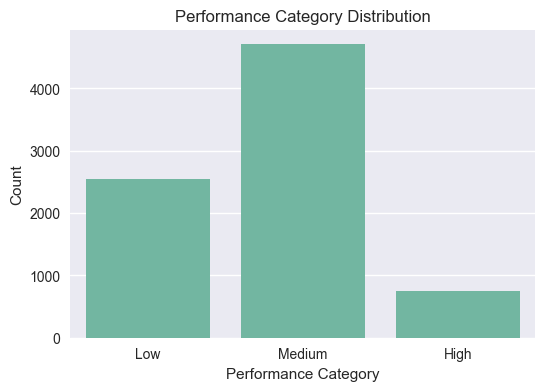

In [6]:
# checking class distribution
print(y.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Performance Category Distribution")
plt.xlabel("Performance Category")
plt.ylabel("Count")
plt.show()

In [7]:
# making a copy so I keep the original safe
X_encoded = X.copy()

# finding categorical columns
cat_cols = X_encoded.select_dtypes(include=["object"]).columns
print("Categorical columns:", list(cat_cols))

Categorical columns: ['gender', 'grade_level', 'ai_tools_used', 'ai_usage_purpose']


In [8]:
# encoding categorical columns
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le

# encoding the target labels too
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

X_encoded.head()

,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,...,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score
0,20,0,3,2.5,1,170,5,2,10,29,...,29,40.9,98.8,4,9.0,8.1,7.2,1.5,4.6,6
1,17,1,2,3.4,1,123,5,4,4,14,...,60,87.2,89.3,8,8.5,13.8,7.6,5.1,2.7,6
2,24,1,5,0.8,0,35,3,1,8,82,...,98,77.1,50.8,7,2.1,39.1,5.7,0.2,4.0,3
3,21,0,2,4.4,0,45,1,4,3,74,...,67,86.4,52.1,5,6.7,25.2,8.2,4.2,2.9,2
4,18,2,5,3.5,1,21,1,0,2,83,...,40,69.4,40.7,5,5.4,2.7,8.7,0.2,2.9,2


In [9]:
# splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (6400, 22)
Test shape: (1600, 22)


In [10]:
# scaling the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (6400, 22)
Scaled test shape: (1600, 22)


In [11]:
# converting target to one-hot encoding
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

y_train_cat shape: (6400, 3)
y_test_cat shape: (1600, 3)


In [12]:
# building the first deep learning model
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\dsml2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,651 (14.26 KB)

 Trainable params: 3,651 (14.26 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# training the model
history = model.fit(
    X_train_scaled,
    y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6580 - loss: 0.8134 - val_accuracy: 0.7820 - val_loss: 0.5968
Epoch 2/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7625 - loss: 0.5619 - val_accuracy: 0.8188 - val_loss: 0.4341
Epoch 3/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7982 - loss: 0.4721 - val_accuracy: 0.8336 - val_loss: 0.3840
Epoch 4/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8066 - loss: 0.4435 - val_accuracy: 0.8406 - val_loss: 0.3690
Epoch 5/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8186 - loss: 0.4208 - val_accuracy: 0.8359 - val_loss: 0.3627
Epoch 6/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8186 - loss: 0.4137 - val_accuracy: 0.8422 - val_loss: 0.3614
Epoch 7/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8254 - loss: 0.3951 - val_accuracy: 0.8430 - val_loss: 0.3575
Epoch 8/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8281 - loss: 0.3893 - val_accu

In [14]:
# evaluating on the test set
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.840624988079071


In [15]:
# predictions
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

        High       0.73      0.68      0.70       151
         Low       0.83      0.85      0.84       508
      Medium       0.86      0.86      0.86       941

    accuracy                           0.84      1600
   macro avg       0.81      0.80      0.80      1600
weighted avg       0.84      0.84      0.84      1600



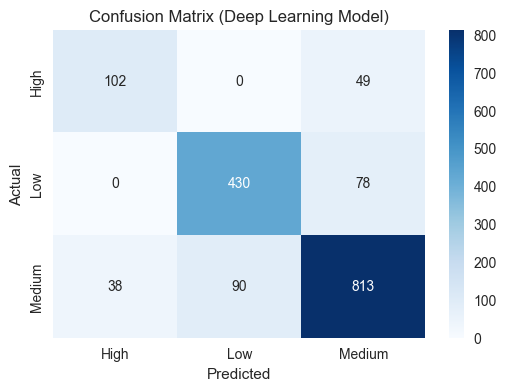

In [16]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title("Confusion Matrix (Deep Learning Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
# function to build a model from a list of hidden layer sizes
def build_model(hidden_layers):
    model = Sequential()
    model.add(Dense(hidden_layers[0], activation="relu", input_shape=(X_train_scaled.shape[1],)))
    model.add(Dropout(0.2))

    for units in hidden_layers[1:]:
        model.add(Dense(units, activation="relu"))
        model.add(Dropout(0.2))

    model.add(Dense(3, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [18]:
# trying a few different architectures
architectures = [
    [32, 16],
    [64, 32],
    [128, 64],
    [64, 32, 16]
]

dl_results = []

for arch in architectures:
    temp_model = build_model(arch)

    temp_history = temp_model.fit(
        X_train_scaled,
        y_train_cat,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    loss, acc = temp_model.evaluate(X_test_scaled, y_test_cat, verbose=0)
    dl_results.append([str(arch), acc])

dl_results_df = pd.DataFrame(dl_results, columns=["architecture", "accuracy"])
dl_results_df

c:\dsml2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,architecture,accuracy
0,"[32, 16]",0.715000
1,"[64, 32]",0.766875
2,"[128, 64]",0.837500
3,"[64, 32, 16]",0.765000


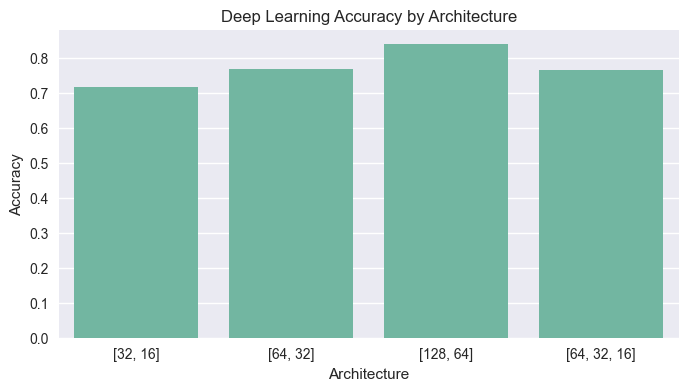

In [19]:
# plotting architecture comparison
plt.figure(figsize=(8, 4))
sns.barplot(data=dl_results_df, x="architecture", y="accuracy")
plt.title("Deep Learning Accuracy by Architecture")
plt.xlabel("Architecture")
plt.ylabel("Accuracy")
plt.show()

In [20]:
# selecting the best architecture
best_architecture = dl_results_df.loc[dl_results_df["accuracy"].idxmax(), "architecture"]
print("Best architecture:", best_architecture)

Best architecture: [128, 64]


In [21]:
# converting the selected architecture back into a list
best_architecture_list = eval(best_architecture)

# building the final model
final_model = build_model(best_architecture_list)

# training the final model
final_history = final_model.fit(
    X_train_scaled,
    y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


c:\dsml2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7223 - loss: 0.6507 - val_accuracy: 0.8320 - val_loss: 0.4212
Epoch 2/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8127 - loss: 0.4328 - val_accuracy: 0.8383 - val_loss: 0.3722
Epoch 3/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8279 - loss: 0.3967 - val_accuracy: 0.8328 - val_loss: 0.3687
Epoch 4/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8348 - loss: 0.3803 - val_accuracy: 0.8328 - val_loss: 0.3644
Epoch 5/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8316 - loss: 0.3778 - val_accuracy: 0.8430 - val_loss: 0.3631
Epoch 6/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8371 - loss: 0.3601 - val_accuracy: 0.8453 - val_loss: 0.3590
Epoch 7/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8473 - loss: 0.3510 - val_accuracy: 0.8469 - val_loss: 0.3597
Epoch 8/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8486 - loss: 0.3500 - val_accuracy: 0.8406

In [22]:
# converting the selected architecture back into a list
best_architecture_list = eval(best_architecture)

# building the final model
final_model = build_model(best_architecture_list)

# training the final model
final_history = final_model.fit(
    X_train_scaled,
    y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6934 - loss: 0.7049 - val_accuracy: 0.8219 - val_loss: 0.4485
Epoch 2/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8033 - loss: 0.4456 - val_accuracy: 0.8359 - val_loss: 0.3815
Epoch 3/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8182 - loss: 0.4072 - val_accuracy: 0.8375 - val_loss: 0.3709
Epoch 4/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8305 - loss: 0.3863 - val_accuracy: 0.8461 - val_loss: 0.3633
Epoch 5/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8377 - loss: 0.3682 - val_accuracy: 0.8406 - val_loss: 0.3706
Epoch 6/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8391 - loss: 0.3604 - val_accuracy: 0.8414 - val_loss: 0.3640
Epoch 7/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8422 - loss: 0.3517 - val_accuracy: 0.8422 - val_loss: 0.3641
Epoch 8/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8506 - loss: 0.3421 - val_accu

In [23]:
# final evaluation
final_loss, final_accuracy = final_model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print("Final Test Accuracy:", final_accuracy)

Final Test Accuracy: 0.8199999928474426


In [24]:
# final predictions
final_pred_probs = final_model.predict(X_test_scaled)
final_preds = np.argmax(final_pred_probs, axis=1)

print(classification_report(y_test, final_preds, target_names=target_encoder.classes_))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

        High       0.80      0.32      0.46       151
         Low       0.83      0.83      0.83       508
      Medium       0.82      0.89      0.85       941

    accuracy                           0.82      1600
   macro avg       0.82      0.68      0.71      1600
weighted avg       0.82      0.82      0.81      1600



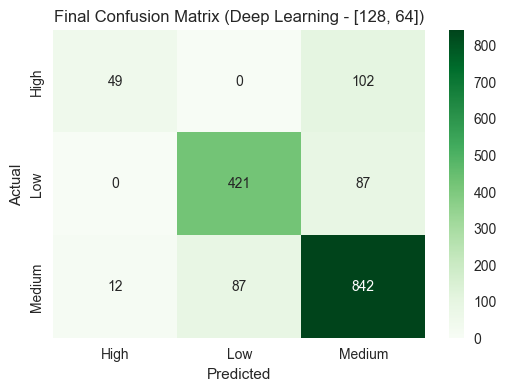

In [25]:
# final confusion matrix
final_cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title(f"Final Confusion Matrix (Deep Learning - {best_architecture})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

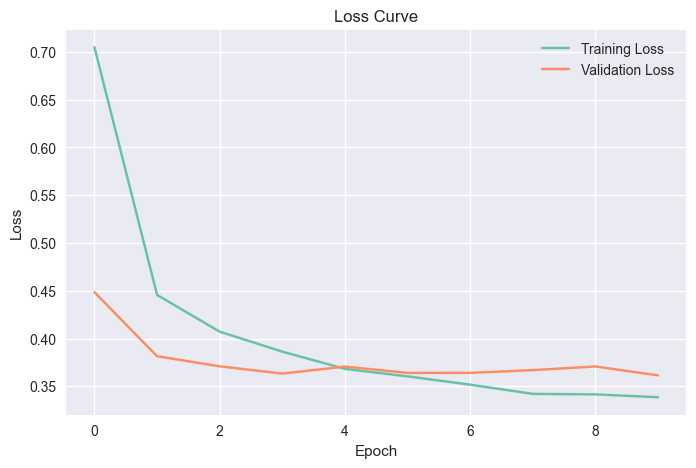

In [26]:
# loss curve
plt.figure(figsize=(8, 5))
plt.plot(final_history.history["loss"], label="Training Loss")
plt.plot(final_history.history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

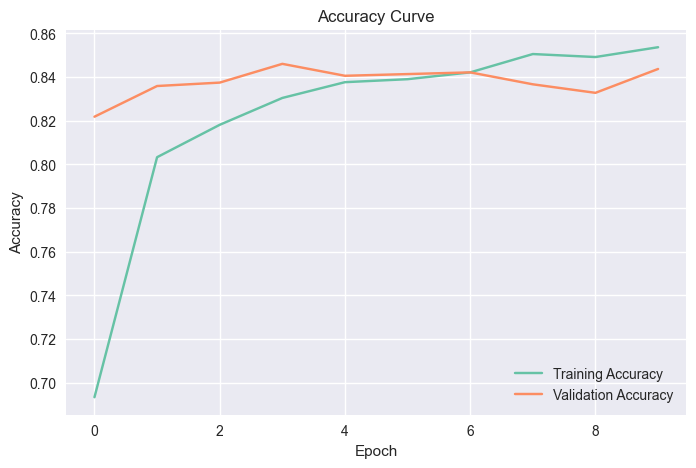

In [27]:
# accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(final_history.history["accuracy"], label="Training Accuracy")
plt.plot(final_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 10. Conclusion

In this notebook I implemented a deep learning model using a dataset about AI and student performance.

### Summary of work completed
- loaded and explored the dataset
- checked and fixed missing values
- selected `performance_category` as the target
- removed `student_id`, `final_score`, and `passed`
- encoded categorical columns
- split the data into training and test sets
- scaled the features
- converted the target to one-hot encoding
- built and trained an initial deep learning model
- evaluated the model using accuracy, classification report, and confusion matrix
- compared several deep learning architectures
- analysed training and validation curves

### Results
The initial deep learning model achieved a **test accuracy of 0.8406**.

Its class-level performance was:
- High: precision **0.73**, recall **0.68**, f1-score **0.70**
- Low: precision **0.83**, recall **0.85**, f1-score **0.84**
- Medium: precision **0.86**, recall **0.86**, f1-score **0.86**

I also compared several alternative architectures:
- [32, 16] → **0.7150**
- [64, 32] → **0.7669**
- [128, 64] → **0.8375**
- [64, 32, 16] → **0.7650**

The best alternative architecture tested was **[128, 64]**, but it did not outperform the initial model. When retrained, its result was lower, which shows that deep learning training can vary between runs.

### Reflection
This notebook gives a deep learning implementation for the semester 2 portfolio. It is stronger than the earlier neural network notebook because it uses TensorFlow/Keras and a deeper model structure.

It also showed that deeper or larger models do not always guarantee better final results. In this case, the simpler initial model achieved the strongest result overall.

Although the notebook title includes transformers, this dataset is tabular rather than text or sequence data, so a dense deep learning model is more suitable here. Transformer architectures are usually more appropriate for text, sequence, or attention-based tasks.
